In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cleaning_utils import clean_dataset2

In [2]:
raw_df = pd.read_csv('OML_4G_DATA_OSS.csv')
df = clean_dataset2(raw_df)

df.head()

,Time,eNodeB_Function_Name,Cell_Name,Frequency_band,Avg_DL_User_Thrput_kbps,Avg_DL_Traffic_Active_User,Date,Hour
0,2024-05-27,1288_KKO_KATI_4G,1288_KKO_KATI_1_L800,20,7543.2661,2.6076,2024-05-27,0
1,2024-05-27,1324_BKO_SOGONIKO_4G,1324_BKO_SOGONIKO_3_L800,20,9686.8516,0.8624,2024-05-27,0
2,2024-05-27,1560_BKO_SENOU-MEDINE_4G,1560_BKO_SENOU-MEDINE_2_L1800,3,12827.9154,1.8092,2024-05-27,0
3,2024-05-27,1605_BKO_NIARELAMosque_4G,1605_BKO_NIARELAMosque_1_L700,28,0.0000,0.0000,2024-05-27,0
4,2024-05-27,1634_BKO_DOUMANZANA_4G,1634_BKO_DOUMANZANA_3_L1800,3,18474.4263,0.7931,2024-05-27,0


### General Dataset Overview

In [3]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes.value_counts())
print("\nDetailed info:")
df.info()

Shape: (5247859, 8)

Data Types:
datetime64[ns]    2
string[python]    2
float64           2
category          1
int64             1
Name: count, dtype: int64

Detailed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5247859 entries, 0 to 5247858
Data columns (total 8 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   Time                        datetime64[ns]
 1   eNodeB_Function_Name        string        
 2   Cell_Name                   string        
 3   Frequency_band              category      
 4   Avg_DL_User_Thrput_kbps     float64       
 5   Avg_DL_Traffic_Active_User  float64       
 6   Date                        datetime64[ns]
 7   Hour                        int64         
dtypes: category(1), datetime64[ns](2), float64(2), int64(1), string(2)
memory usage: 285.3 MB


In [4]:
# Categorical summary
cat_cols = df.select_dtypes(include=['category']).columns
for col in cat_cols:
    print(f"\nColumns: {col}")
    print(df[col].value_counts(dropna=False))


Columns: Frequency_band
Frequency_band
20    2082184
3     1615832
28     935694
7      606433
40       7716
Name: count, dtype: int64


In [5]:
# Date summary
print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print("Date Frequency Breakdown:")
print(df['Date'].dt.to_period('M').value_counts().sort_index())


Date Range: 2024-05-27 00:00:00 to 2025-07-30 00:00:00
Date Frequency Breakdown:
Date
2024-05     56348
2024-06    339822
2024-07    352814
2024-08    354367
2024-09    343097
2024-10    356479
2024-11    352423
2024-12    373362
2025-01    391278
2025-02    358450
2025-03    401498
2025-04    391676
2025-05    405715
2025-06    391568
2025-07    378962
Freq: M, Name: count, dtype: int64


In [6]:
# Descriptive stats for numeric columns
numeric_cols = df.select_dtypes(include=['int', 'float']).columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Avg_DL_User_Thrput_kbps,5247859.0,15814.126172,12008.431785,0.0,7011.31515,13287.0156,21643.39085,260082.1326
Avg_DL_Traffic_Active_User,5247859.0,4.119602,12.665879,0.0,0.46960,1.1420,2.78890,685.5966
Hour,5247859.0,19.211255,4.594153,0.0,20.00000,21.0000,22.00000,23.0000


### Univariate Analysis

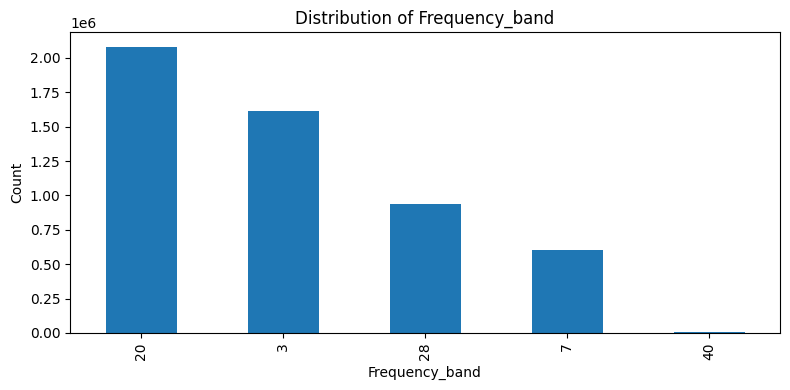

In [7]:
# Bar plots
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

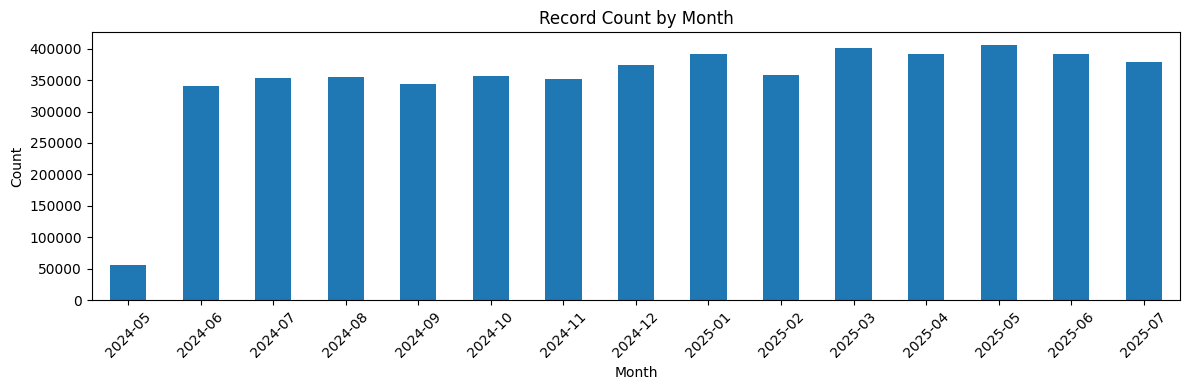

In [8]:
# Date summary
df['Date'].dt.to_period('M').value_counts().sort_index().plot(kind='bar', figsize=(12, 4))
plt.title('Record Count by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

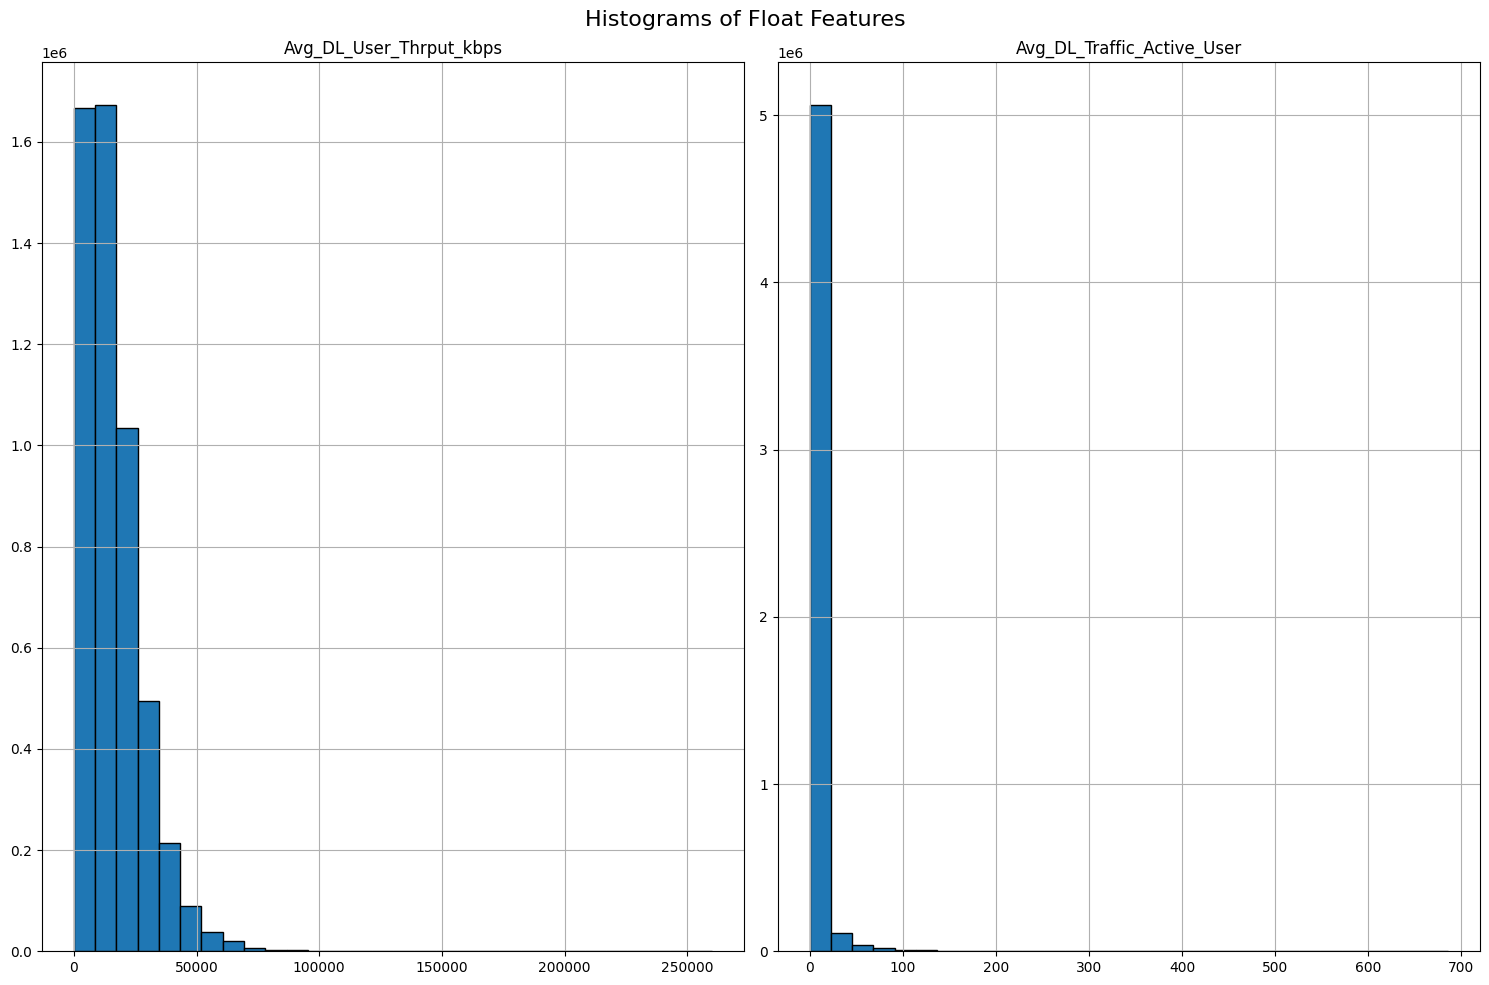

In [9]:
# Float columns histograms
df[numeric_cols].hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle('Histograms of Float Features', fontsize=16)
plt.tight_layout()
plt.show()

### Bivariate Analysis

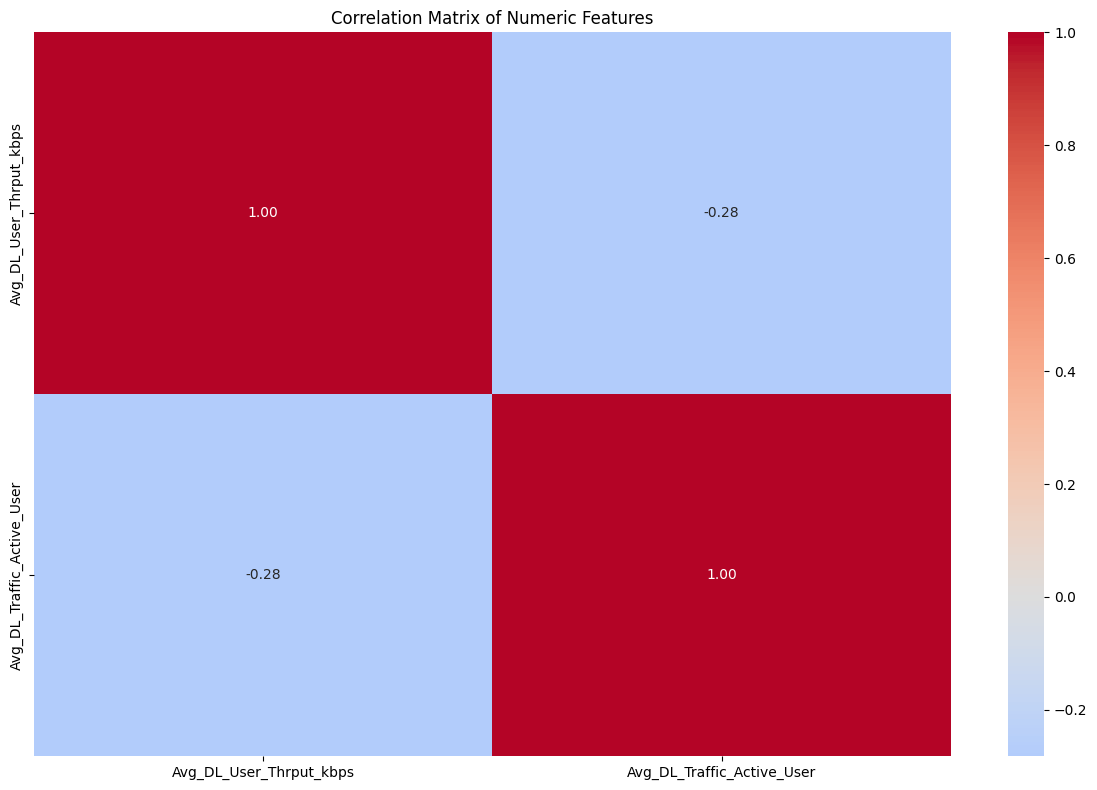

In [10]:
# Correlation Matrix
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()